# IA3

在 Transformer 注意力层中的缩放机制
以 Transformer 的自注意力为例（  $\mathrm{Q} 、 \mathrm{~K} 、 \mathrm{~V}$  的计算）：

$$\begin{array}{c}
Q=X W_{Q}, \quad K=X W_{K}, \quad V=X W_{V} \\
\text { Attention }(Q, K, V)=\operatorname{softmax}\left(\frac{Q K^{T}}{\sqrt{d_{k}}}\right) V
\end{array}$$


$IA^{3} $ 在这里的核心操作是：
在 V 的输出上插入一个可学习缩放向量  $\lambda_{v} $

于是改写为：

$$\begin{array}{c}
V^{\prime}=\left(X W_{V}\right) \odot \lambda_{v} \\
\text { Attention }\left(Q, K, V^{\prime}\right)=\operatorname{softmax}\left(\frac{Q K^{T}}{\sqrt{d_{k}}}\right) V^{\prime}
\end{array}$$


其中：
-  $\odot$  表示逐通道（或逐维）乘法；
-  $\lambda_{v} \in \mathbb{R}^{d_{v}}$  是可训练参数；
- 初始值一般设为 1 （即不改变原模型输出）。

Transformer 的前馈层通常是：
$$\begin{align*}
h &= \text{GELU}(XW_1 + b_1) \\
Y &= hW_2 + b_2
\end{align*}$$

$IA^{3}$ 可以在这里同样插入缩放：
$$\begin{aligned}
h' &= \text{GELU}(XW_1 + b_1) \\
h'' &= h' \odot \lambda_{\text{ff}} \\
Y &= h''W_2 + b_2
\end{aligned}$$

这里 $\lambda_{\text{ff}}$ 是与隐藏维度相同长度的缩放向量。

In [1]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorForSeq2Seq, TrainingArguments, Trainer

## 加载数据集/tokenizer 以及数据处理

In [2]:
data_path = "/root/autodl-tmp/dataset/alpaca-gpt4-data-zh/alpaca_gpt4_data_zh.json"
ds = load_dataset("json", data_files=data_path, split="train")

path = "model/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(path)
print("tokenizer.eos_token is: ", tokenizer.eos_token)

tokenizer.eos_token is:  <|im_end|>


In [3]:
def process_func(example):
    MAX_LENGTH = 256
    input_ids, attention_mask, labels = [], [], []

    instruction = tokenizer(
        "\n".join(["Human: " + example["instruction"], example["input"]]).strip() + "\n\nAssistant: "
    )

    response = tokenizer(example["output"] + tokenizer.eos_token)
    input_ids = instruction["input_ids"] + response["input_ids"]
    attention_mask = instruction["attention_mask"] + response["attention_mask"]
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"]

    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
        
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }
tokenized_ds = ds.map(process_func, remove_columns=ds.column_names)
tokenized_ds, tokenizer.decode(tokenized_ds[1]["input_ids"])

(Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 48818
 }),
 'Human: 三原色是什么？\n\nAssistant: 三原色通常指的是红色、绿色和蓝色（RGB）。它们是通过加色混合原理创建色彩的三种基础颜色。在以发光为基础的显示设备中（如电视、计算机显示器、智能手机和平板电脑显示屏）, 三原色可混合产生大量色彩。其中红色和绿色可以混合生成黄色，红色和蓝色可以混合生成品红色，蓝色和绿色可以混合生成青色。当红色、绿色和蓝色按相等比例混合时，可以产生白色或灰色。\n\n此外，在印刷和绘画中，三原色指的是以颜料为基础的红、黄和蓝颜色（RYB）。这三种颜色用以通过减色混合原理来创建色彩。不过，三原色的具体定义并不唯一，不同的颜色系统可能会采用不同的三原色。<|im_end|>')

In [4]:
train_test_split = tokenized_ds.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test_split['train']
eval_dataset = train_test_split['test']
print(train_dataset, eval_dataset)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 39054
}) Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 9764
})


## 创建模型

In [5]:
model = AutoModelForCausalLM.from_pretrained(path)


## 参数配置

In [6]:
from peft import IA3Config, TaskType, get_peft_model

config = IA3Config(
            task_type=TaskType.CAUSAL_LM,
            target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
            # feedforward_modules=["down_proj"],
)
config

IA3Config(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.IA3: 'IA3'>, auto_mapping=None, base_model_name_or_path=None, revision=None, inference_mode=False, target_modules={'o_proj', 'q_proj', 'v_proj', 'k_proj'}, exclude_modules=None, feedforward_modules=None, fan_in_fan_out=False, modules_to_save=None, init_ia3_weights=True)

In [7]:
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 143,360 || all params: 596,193,280 || trainable%: 0.0240


可以和lora进行对比，**参数量少了一大截**：

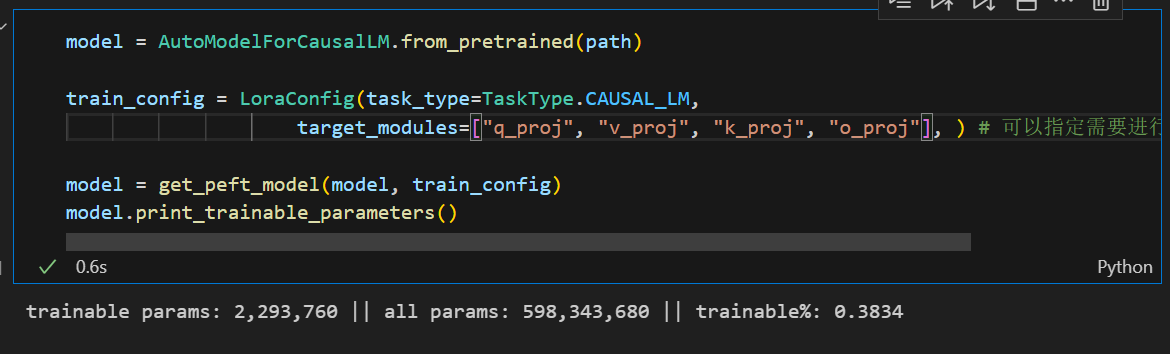

In [10]:
model

PeftModelForCausalLM(
  (base_model): IA3Model(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 1024)
        (layers): ModuleList(
          (0-27): 28 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): Linear(
                (base_layer): Linear(in_features=1024, out_features=2048, bias=False)
                (ia3_l): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 2048x1 (cuda:0)])
              )
              (k_proj): Linear(
                (base_layer): Linear(in_features=1024, out_features=1024, bias=False)
                (ia3_l): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 1024x1 (cuda:0)])
              )
              (v_proj): Linear(
                (base_layer): Linear(in_features=1024, out_features=1024, bias=False)
                (ia3_l): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor o

## 训练

In [8]:
args = TrainingArguments(
    output_dir="./chatbot/lora",
    learning_rate=5e-4,
    per_device_train_batch_size=12,
    gradient_accumulation_steps=1,
    logging_steps=10,
    num_train_epochs=1,
    save_steps=500,
    logging_dir="../tf-logs/ia3/rus",       
    report_to="tensorboard",
    eval_strategy="steps",
    eval_steps=400,             
)

trainer = Trainer(
    model=model,
    args=args,
    processing_class=tokenizer,
    eval_dataset=eval_dataset,
    train_dataset=train_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
)

In [9]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
400,1.854900,1.862427
800,1.909900,1.842385
1200,1.885900,1.833434
1600,1.831800,1.828338
2000,1.936600,1.824808
2400,1.855800,1.822764
2800,1.794900,1.821549
3200,1.759900,1.821012


TrainOutput(global_step=3255, training_loss=1.8433796866515082, metrics={'train_runtime': 2126.9029, 'train_samples_per_second': 18.362, 'train_steps_per_second': 1.53, 'total_flos': 2.617938864164045e+16, 'train_loss': 1.8433796866515082, 'epoch': 1.0})

In [14]:
model.cuda()
ipt = tokenizer("Human: {}\n{}".format("如何对线性代数进行高效的学习？", "").strip() + "\n\nAssistant: ", return_tensors="pt").to(model.device)
out = tokenizer.decode(model.generate(**ipt, max_length=512, do_sample=True)[0], skip_special_tokens=True)
print(out)

Human: 如何对线性代数进行高效的学习？

Assistant: 学习线性代数是一项很有效的学习过程，可以通过以下方法来进行高效的学习：

1. 学习线性代数的基本概念：线性代数是数学中关于向量、矩阵、线性空间和线性变换的基本概念，学习这些概念有助于你理解线性代数的基本原理。

2. 学习线性代数的运算规则：线性代数涉及向量、矩阵、线性变换和线性组合等基本概念，学习这些运算规则有助于你掌握线性代数的基本运算。

3. 学习线性代数的性质和定理：线性代数涉及许多重要的性质和定理，例如行列式、特征值、矩阵的逆、行列式、特征值、特征向量等。学习这些性质和定理有助于你掌握线性代数的性质和定理。

4. 学习线性代数的应用：线性代数在许多实际问题中都有应用，例如在物理、工程、计算机科学等领域。学习线性代数的应用可以帮助你更好地理解线性代数的实际意义。

5. 学习线性代数的编程语言：学习线性代数涉及到许多编程语言，例如Python、C++、Java等。学习这些编程语言可以帮助你更好地理解线性代数的实际应用。

6. 学习线性代数的编程方法：学习线性代数涉及到许多编程方法，例如线性代数的矩阵运算、向量运算、线性变换等。学习这些编程方法可以帮助你更好地理解线性代数的实际应用。

7. 学习线性代数的算法：学习线性代数涉及许多算法，例如矩阵求逆、矩阵求积、矩阵求积等。学习这些算法可以帮助你更好地理解线性代数的实际应用。

总之，学习线性代数是一项非常高效的学习过程，可以通过以上这些方法来进行高效的学习。


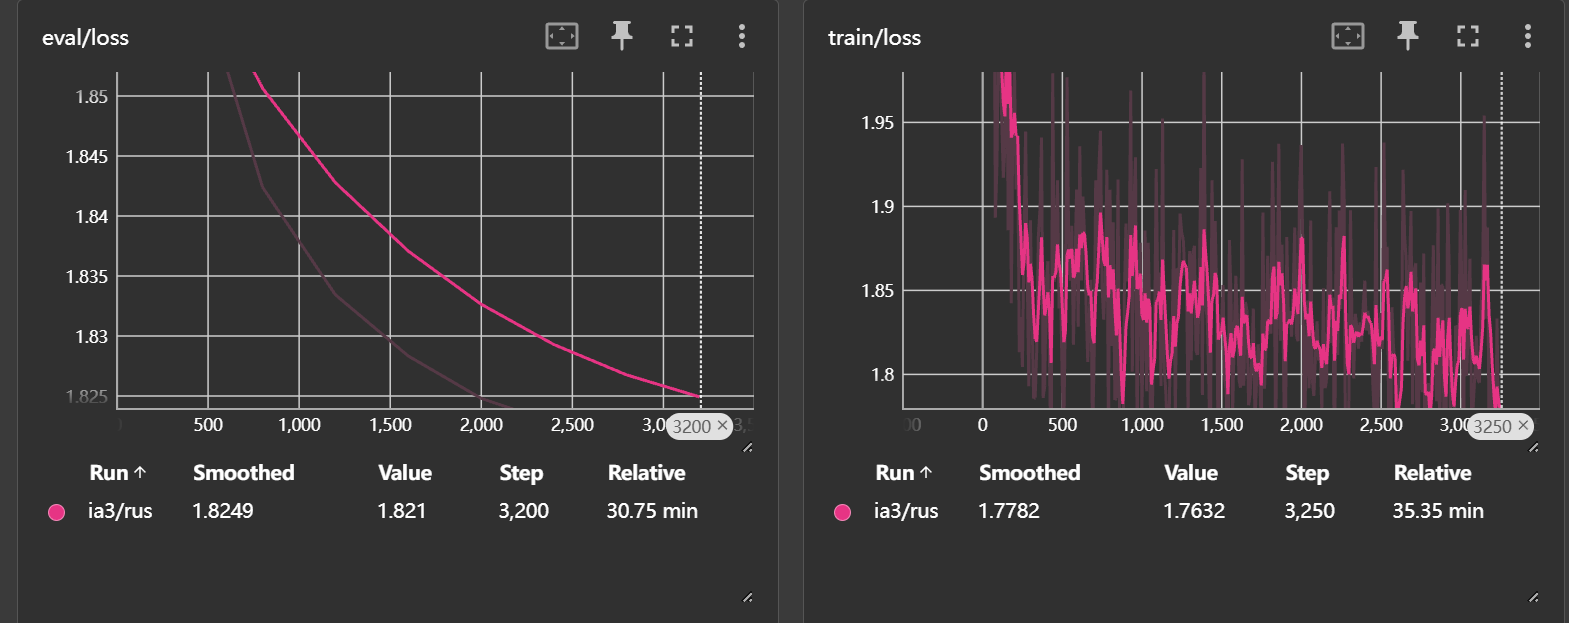

## 模型保存

pass